#### **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Importing Data**

In [2]:
df = pd.read_csv("blinkit_data.csv")

#### **Sample Data**

In [3]:
df.head(20)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


### **About Data**

In [4]:
df.shape

(8523, 12)

The dataset contains 8,523 records and 12 features, representing item-level sales data across multiple outlets.

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


The dataset contains both numerical and categorical variables. 
Missing values are present in item-weight

In [9]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


#### **NULL Value Checking**

In [8]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

Sales values show high variation, indicating that revenue contribution is uneven across items. 
This suggests the presence of high-performing and low-performing products.

#### **Handling inconsistent Values**

In [10]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [11]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF' : 'Low Fat',
                                                        'low fat' : 'Low Fat',
                                                        'reg' : 'Regular'})

##### Inconsistent values in the `Item Fat Content` column were standardized to improve data quality. This cleaning step enables accurate grouping and comparison across fat content categories.

In [ ]:
#### **Creating Outlet **

In [22]:
df['Outlet_Age'] = 2025 - df['Outlet Establishment Year']
df

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,Outlet_Age
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0,13
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0,3
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0,15
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0,25
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,Low Fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0,27
8519,Low Fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0,27
8520,Low Fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0,27
8521,Regular,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0,27


##### A new column `Outlet_Age` was created by calculating the difference between the current year (2025) and the outlet establishment year. This helps analyze how the age of an outlet impacts its sales performance.

#### **Calculating Business KPI's**

In [13]:
#Total Sales
total_sales = df['Sales'].sum()

#Avg Sales
avg_sales = df['Sales'].mean()

#No. of Items Sold
total_items_sold = df['Item Identifier'].count()

#Avg Rating
avg_rating = df['Rating'].mean()

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${avg_sales:,.2f}")
print(f"Total Items Sold: {total_items_sold:,.0f}")
print(f"Average Rating: {avg_rating:,.1f}")

Total Sales: $1,201,681
Average Sales: $140.99
Total Items Sold: 8,523
Average Rating: 4.0


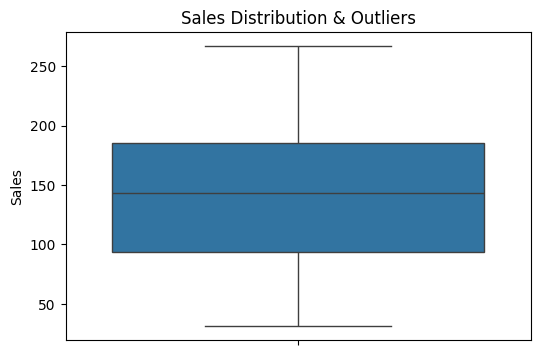

In [69]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Sales'])
plt.title("Sales Distribution & Outliers")
plt.show()

#### **Rating Distribution**

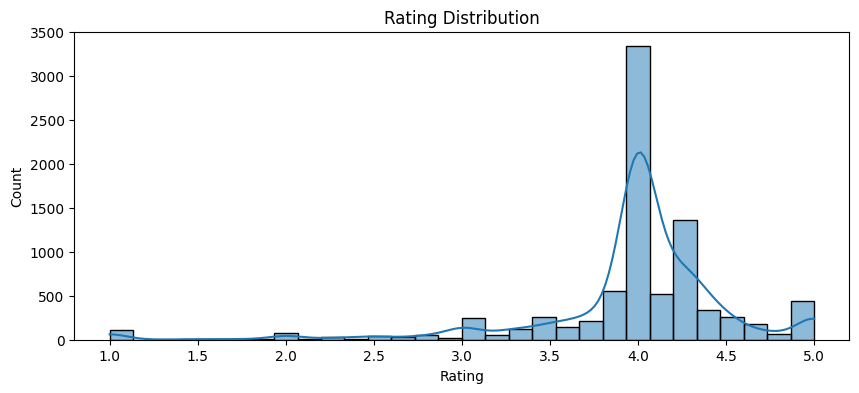

In [48]:
plt.figure(figsize=(10,4))
sns.histplot(df['Rating'], bins=30, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

##### Ratings are highly concentrated between 3.5 and 4.5, indicating generally positive customer feedback. Very low ratings are rare, suggesting consistent service and product quality across outlets.

In [53]:
df.groupby('Outlet Type')['Sales'].sum().sort_values(ascending=False)

Outlet Type
Supermarket Type1    787549.8868
Grocery Store        151939.1470
Supermarket Type2    131477.7724
Supermarket Type3    130714.6746
Name: Sales, dtype: float64

##### Supermarket Type1 generates the highest total sales, significantly outperforming all other outlet types. This highlights its dominant role in overall revenue contribution.

In [57]:
df.groupby('Outlet Size')['Sales'].sum().sort_values(ascending=False)

Outlet Size
Medium    507895.7284
Small     444794.1684
High      248991.5840
Name: Sales, dtype: float64

##### Medium-sized outlets contribute the highest total sales, followed by small and large outlets. This suggests that medium-sized outlets achieve an optimal balance between scale and operational efficiency.

In [68]:
df.groupby('Rating')['Sales'].sum().sort_values(ascending=False).head(5)

Rating
4.0    475733.6056
4.3     95714.5790
4.2     93304.8346
4.1     71333.3722
5.0     59282.5424
Name: Sales, dtype: float64

##### Products with a rating of 4.0 generate the highest total sales, followed by ratings between 4.1 and 4.3. This indicates a strong positive relationship between customer ratings and sales performance.

In [61]:
df.groupby('Outlet_Age')['Sales'].sum().sort_index(ascending=True)

Outlet_Age
3     131477.7724
5     129103.9564
8     133103.9070
10    130942.7782
13    130476.8598
14     78131.5646
15    132113.3698
25    131809.0156
27    204522.2570
Name: Sales, dtype: float64

##### Sales performance differs by outlet age, showing that outlet maturity plays a role in revenue generation.

In [62]:
df.pivot_table(
    values='Sales',
    index='Outlet Type',
    columns='Outlet Location Type',
    aggfunc='mean'
)


Outlet Location Type,Tier 1,Tier 2,Tier 3
Outlet Type,,,
Grocery Store,139.787088,NaN,140.777594
Supermarket Type1,141.177543,141.167196,141.425982
Supermarket Type2,NaN,NaN,141.678634
Supermarket Type3,NaN,NaN,139.801791


##### Supermarket Type1 shows consistently strong and stable average sales across all location tiers (Tier 1, Tier 2, and Tier 3), indicating it performs well irrespective of city size.

### **Items by Fat Content**

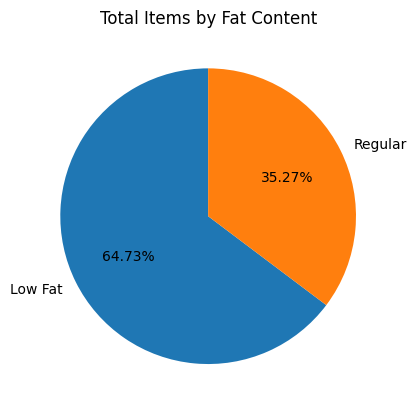

In [49]:
fat_by_sales = df.groupby('Item Fat Content')['Item Fat Content'].count()

plt.pie(fat_by_sales, labels=fat_by_sales.index,
                       autopct = "%.2f%%",
                       startangle = 90)
plt.title("Total Items by Fat Content")
plt.show()

##### Low-fat contribute significantly higher, indicating dominance of a single category.

### **Sales by Item Type**

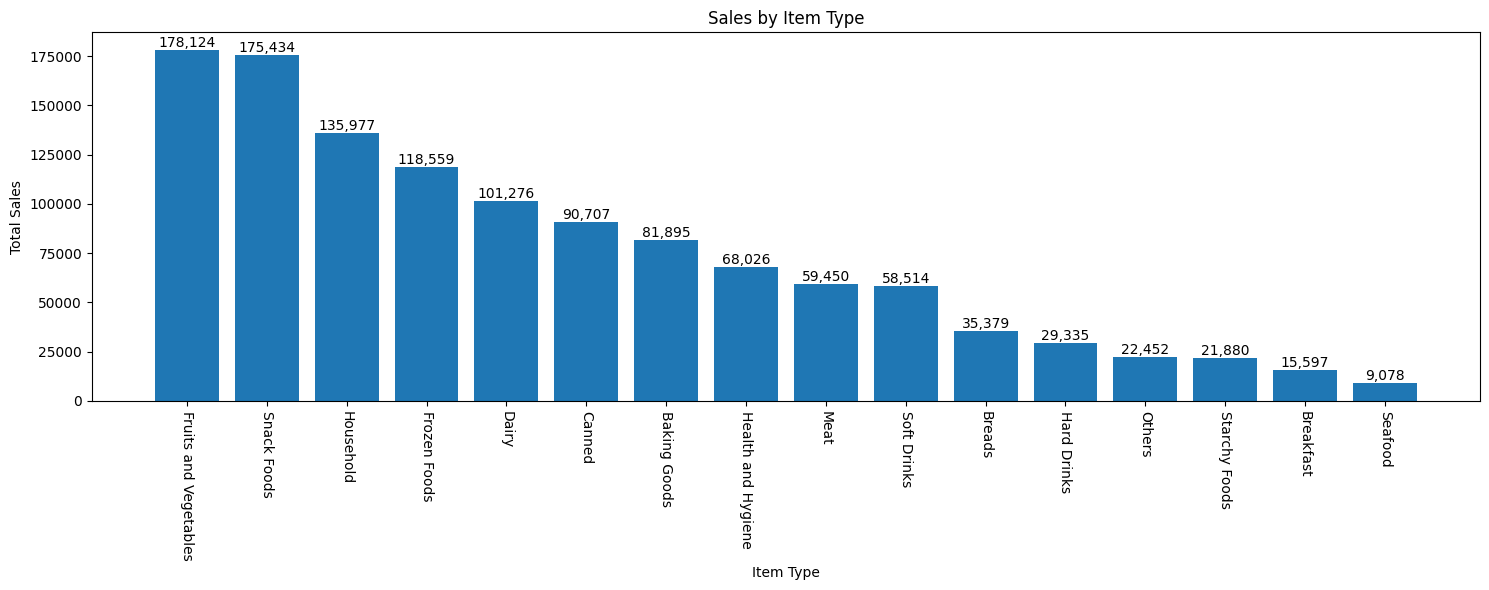

In [87]:
sales_item_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(15,6))
bars = plt.bar(sales_item_type.index, sales_item_type.values)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X position
        height,                             # Y position
        f'{height:,.0f}',                    # Label (no %)
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.xticks(rotation=-90)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Sales by Item Type")
plt.tight_layout()
plt.show()



##### Sales vary significantly across item categories. A few item types generate consistently higher sales, while several categories underperform, indicating uneven revenue contribution across products.

### **Sales by Outlet Establishment Year**

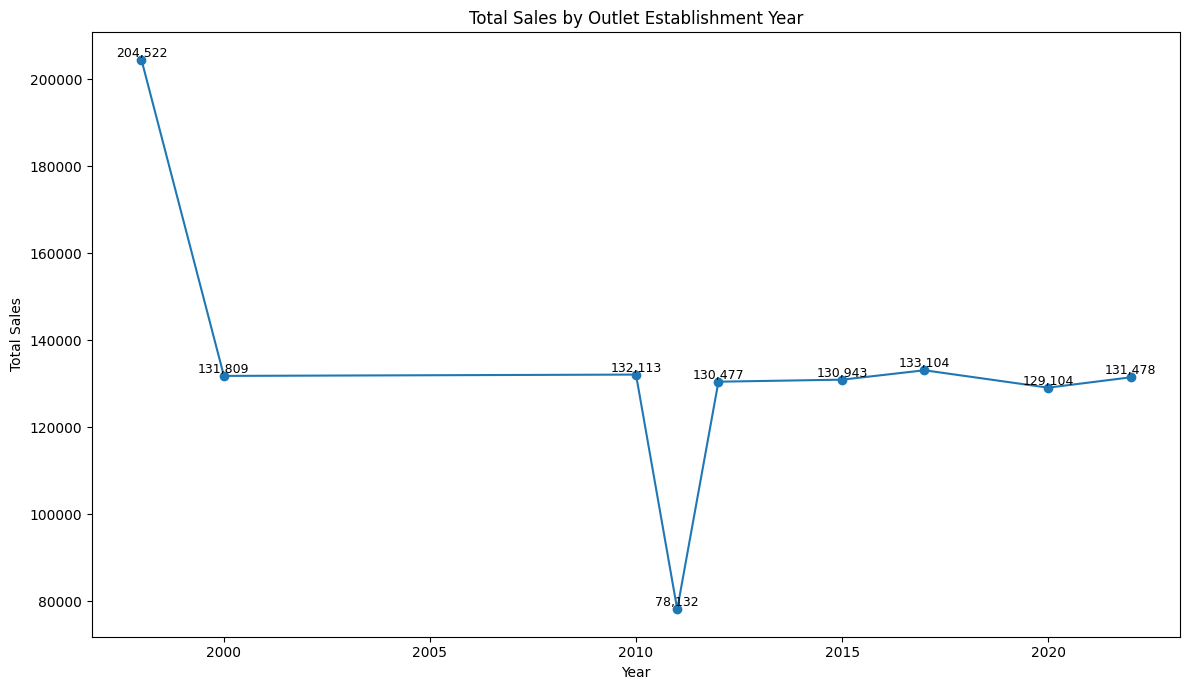

In [86]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(12,7))
plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker='o',
    linestyle='-'
)

# Add value labels on points
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(
        x, y,
        f'{y:,.0f}',     # normal number
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Total Sales by Outlet Establishment Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##### Older outlets tend to generate higher total sales, indicating that operational maturity and customer familiarity may positively influence revenue.

### **Sales by Outlet Size**

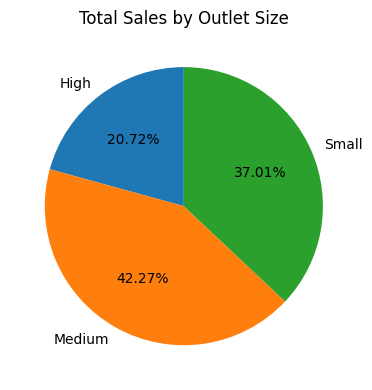

In [18]:
sales_by_outlet_size = df.groupby('Outlet Size')['Sales'].sum()
plt.figure(figsize=(4,4))
plt.pie(sales_by_outlet_size, labels=sales_by_outlet_size.index,
                       autopct = "%.2f%%",
                       startangle = 90)
plt.title("Total Sales by Outlet Size")
plt.tight_layout()
plt.show()

##### Medium outlets contribute significantly higher total sales compared to small outlets and High Outlets, highlighting store size as a key revenue driver.

#### **Sales by Outlet Type**

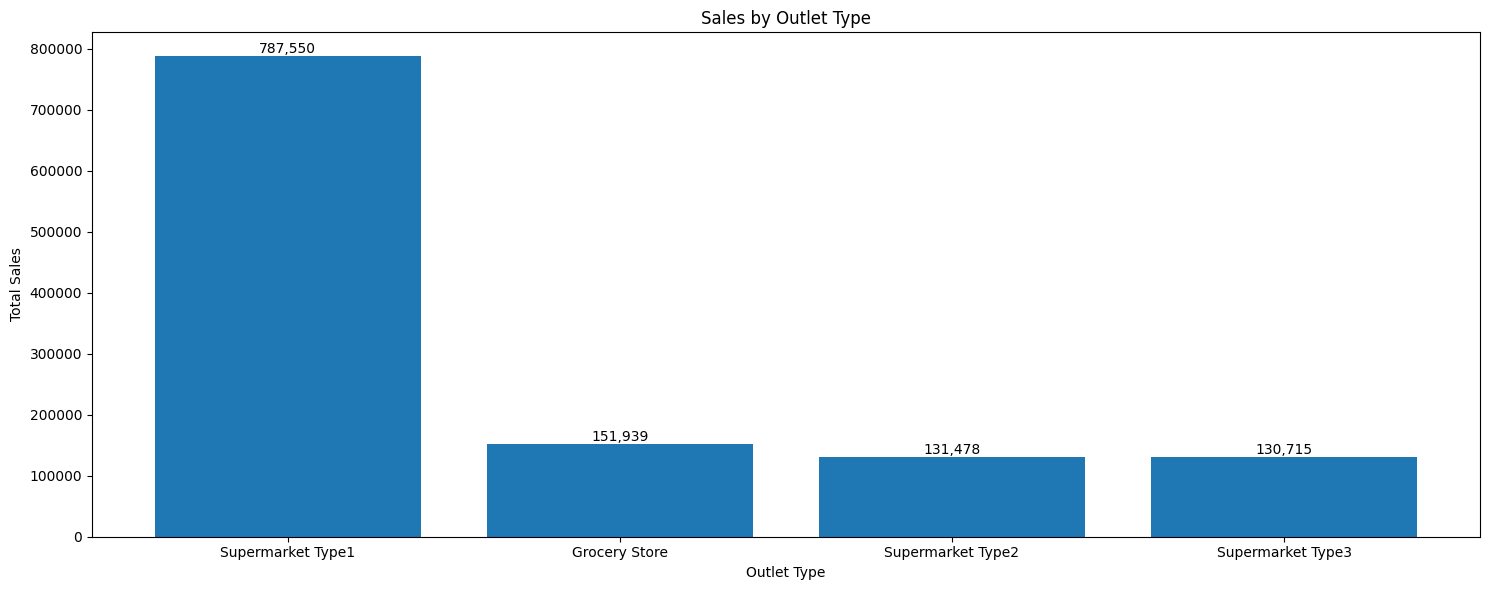

In [83]:
sales_outlet_type = df.groupby('Outlet Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,6))
bars = plt.bar(sales_outlet_type.index, sales_outlet_type.values)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X position
        height,                             # Y position
        f'{height:,.0f}',                    # Label (no %)
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.title("Sales by Outlet Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##### Supermarket-type1 outlets dominate total sales, whereas grocery stores, Supermarket-type2, Supermarket-type3 contribute relatively less, suggesting outlet format has a strong impact on sales performance.

### **Sales by Outlet Location**

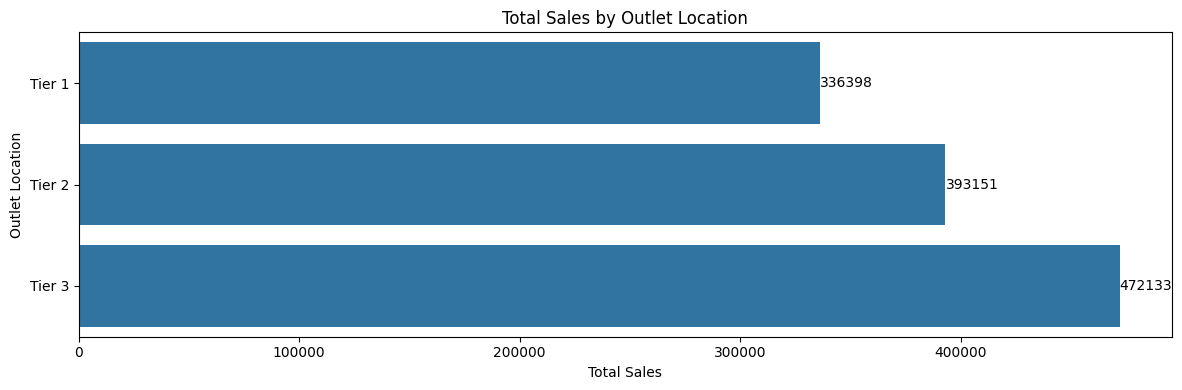

In [81]:
sales_outlet_loc = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()

plt.figure(figsize=(12,4))
ax = sns.barplot(x = 'Sales', y = 'Outlet Location Type', data = sales_outlet_loc)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.title("Total Sales by Outlet Location")
plt.xlabel("Total Sales")
plt.ylabel("Outlet Location")
plt.tight_layout()
plt.show()

##### Tier 3 locations contribute the highest share of total sales, highlighting strong demand and growth potential in smaller cities.